# Market-Rule-Informed LSTM (MR-LSTM)
## Fully Self-Contained Google Colab Notebook

This notebook implements **MR-LSTM** — a recurrent extension of the Market-Rule-Informed Neural Network (MRINN).

### Architecture Diagram
Below is the data flow showing how sequence inputs are processed by LSTM Encoders and passed through the physical market rules to generate quantile forecasts:

```
                           [ 17 Input Sequences (T, 1) ]
                                         │
                                         ▼
                      [ Parallel LSTM Encoders (Cell: LSTM) ]
                                         │
                                         ▼
                        [ Latent Vector Representations (H,) ]
                                         │
                 ┌───────────────────────┼───────────────────────┐
                 ▼                       ▼                       ▼
           [ Rule 1: P_RE ]        [ Rule 2: P_EX ]        [ Rule 3: P_SC ]
         Reserve Activation     Exchange Reference      Scarcity Component
                 │                       │                       │
                 └───────────────────────┼───────────────────────┘
                                         ▼
                        [ Softmax Gate (Min/Max Pricing) ]
                                         │
                                         ▼
                        [ Hierarchical Quantile Head (Q50) ]
                                         │
                                         ▼
                         [ Non-crossing Quantiles (q) ]
```

### Notebook Cell Roadmap
* **Cells 1–2 (Setup & Imports):** Configures Python environment, installs `holidays`, and loads TensorFlow/Keras.
* **Cell 3 (Seed):** Ensures reproducibility of training runs on CPU.
* **Cell 4 (Data Pipeline):** Custom sequences and robust scaling functions designed specifically for recurrent time-series.
* **Cell 5 (Market Constants):** Loads and scales Austrian market thresholds (like price and capacity caps).
* **Cells 6–7 (Market Rules & Visualization):** Formulates differentiable reserve, exchange, and scarcity price rules, and plots their curves.
* **Cells 8–9 (Architecture & Metrics):** Builds LSTM encoders, gates rules together, attaches the non-crossing Quantile Head, and defines custom metrics.
* **Cells 10–16 (Execution & Evaluation):** Loads data, trains the model, runs inference, outputs predictions CSV, and plots evaluation figures.


## 1. Install & Import Dependencies

In this cell, we import all required libraries including NumPy, Pandas, Scikit-Learn, Matplotlib, and TensorFlow. We also try to import `holidays` to match the exact baseline feature set.


In [1]:
try:
    import holidays
except ImportError:
    !pip install -q holidays
    import holidays

import os, sys, time, random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from typing import List, Sequence, Tuple
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import keras
from keras import ops as K

print(f"TensorFlow {tf.__version__}  |  NumPy {np.__version__}")


2026-08-14 18:37:09.840323: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-14 18:37:09.841092: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-14 18:37:09.844566: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-14 18:37:09.855510: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-14 18:37:09.880323: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

2026-08-14 18:37:11.018767: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TensorFlow 2.16.2  |  NumPy 1.26.4


## 2. Reproducibility Seed

Here we lock Python, NumPy, and TensorFlow random seeds. This ensures that every run on CPU produces identical initialization weights and results.


In [2]:
SEED = 42

def set_random_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

set_random_seed(SEED)
print("Seed set:", SEED)


Seed set: 42


## 3. Data Pipeline: Shifting & Recurrent-Aware Scaling

This section prepares sequence-shaped inputs. It contains the following custom functions:
- **`load_data`**: Loads price and capacity features from the CSV and sets Day-Ahead liquidity cap column (`L_DA`) to 0 (which Keras prunes automatically).
- **`split_data`**: Splits datasets chronologically (Training: 2022 to mid-2025, Validation: mid-2025 to Sep-2025, Testing: Sep-2025 to Jan-2026).
- **`scale_data_shared_lags`**: Fits a single RobustScaler on each feature across all its lags. Standard scalers scale columns independently, which would warp time-series dynamics for recurrent networks.


In [3]:
# ─── Column lists ────────────────────────────────────────────────────────────
FEATS_PRICES     = ["P_aFRR_pos", "P_mFRR_pos", "P_aFRR_neg", "P_mFRR_neg",
                    "P_aFRR_pos_MOL", "P_aFRR_neg_MOL",
                    "P_ID15_nemo", "P_ID60_nemo", "P_DA_nemo"]
FEATS_CAPACITIES = ["L_ID15", "L_ID60", "L_DA"]
FEATS_VOLUME     = ["system_imbalance", "E_aFRR_pos", "E_mFRR_pos",
                    "E_aFRR_neg", "E_mFRR_neg"]
LABEL            = ["imbalance_price"]
ALL_FEATS        = FEATS_PRICES + FEATS_CAPACITIES + FEATS_VOLUME

# (dataframe_base, model_input_name) — ORDER IS POSITIONAL, DO NOT REARRANGE
FEATURE_SPEC: List[Tuple[str, str]] = [
    ("system_imbalance",  "system_imbalance"),
    ("E_aFRR_pos",        "E_aFRR_pos_in"),
    ("E_mFRR_pos",        "E_mFRR_pos_in"),
    ("P_aFRR_pos",        "P_aFRR_pos_in"),
    ("P_mFRR_pos",        "P_mFRR_pos_in"),
    ("E_aFRR_neg",        "E_aFRR_neg_in"),
    ("E_mFRR_neg",        "E_mFRR_neg_in"),
    ("P_aFRR_neg",        "P_aFRR_neg_in"),
    ("P_mFRR_neg",        "P_mFRR_neg_in"),
    ("P_aFRR_pos_MOL",    "P_VoAA_pos_in"),
    ("P_aFRR_neg_MOL",    "P_VoAA_neg_in"),
    ("P_ID15_nemo",       "P_ID15_nemo_in"),
    ("P_ID60_nemo",       "P_ID60_nemo_in"),
    ("P_DA_nemo",         "P_DA_nemo_in"),
    ("L_ID15",            "L_ID15_in"),
    ("L_ID60",            "L_ID60_in"),
    ("L_DA",              "L_DA_in"),
]
FEATURE_BASES = [b for b, _ in FEATURE_SPEC]
INPUT_NAMES   = [n for _, n in FEATURE_SPEC]

# ─── Load ────────────────────────────────────────────────────────────────────
def load_data(path: str):
    time_cols = ["Time [UTC] start", "Time [UTC] end"]
    df = pd.read_csv(path, parse_dates=time_cols)
    df.rename(columns={"P_VoAA_pos": "P_aFRR_pos_MOL",
                        "P_VoAA_neg": "P_aFRR_neg_MOL"}, inplace=True)
    df["L_DA"] = 0      # pinned to 0; Keras prunes this branch
    return df

# ─── Split ───────────────────────────────────────────────────────────────────
def split_data(df, train_range, val_range, test_range):
    def mask(r):
        return (df["Time [UTC] start"] >= pd.to_datetime(r[0])) & \
               (df["Time [UTC] start"] <  pd.to_datetime(r[1]))
    return df.loc[mask(train_range)].copy(), \
           df.loc[mask(val_range)].copy(), \
           df.loc[mask(test_range)].copy()

# ─── Lag shift ───────────────────────────────────────────────────────────────
def make_shifts(df, cols, shifts):
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            continue
        for L in shifts:
            out[f"{c}_lag{L}"] = out[c].shift(L)
    return out

def shift_data(df_train, df_val, df_test, target_col, lag_cols, lags):
    lag_names = [f"{c}_lag{L}" for c in lag_cols for L in lags]
    needed = lag_names + [target_col, "Time [UTC] start"]
    tr = make_shifts(df_train, lag_cols, lags)[needed].dropna().copy()
    va = make_shifts(df_val,   lag_cols, lags)[needed].dropna().copy()
    te = make_shifts(df_test,  lag_cols, lags)[needed].dropna().copy()
    return tr, va, te, lag_names

# ─── Shared-lag scaler (recurrent-aware) ─────────────────────────────────────
def scale_data_shared_lags(tr, va, te, feature_names, target_col):
    """One RobustScaler per signal across all its lag columns.
    This preserves the relative ordering of the time axis for the LSTM.
    """
    groups = {}
    for col in feature_names:
        base = col.rsplit("_lag", 1)[0] if "_lag" in col else col
        groups.setdefault(base, []).append(col)

    Xtr = tr[feature_names].to_numpy(dtype=float).copy()
    Xva = va[feature_names].to_numpy(dtype=float).copy()
    Xte = te[feature_names].to_numpy(dtype=float).copy()
    idx_of = {c: i for i, c in enumerate(feature_names)}

    for cols in groups.values():
        idx = [idx_of[c] for c in cols]
        sc = RobustScaler().fit(Xtr[:, idx].reshape(-1, 1))
        for i in idx:
            Xtr[:, i] = sc.transform(Xtr[:, i].reshape(-1, 1)).ravel()
            Xva[:, i] = sc.transform(Xva[:, i].reshape(-1, 1)).ravel()
            Xte[:, i] = sc.transform(Xte[:, i].reshape(-1, 1)).ravel()

    ytr = tr[target_col].to_numpy(dtype=float).reshape(-1, 1)
    yva = va[target_col].to_numpy(dtype=float).reshape(-1, 1)
    yte = te[target_col].to_numpy(dtype=float).reshape(-1, 1)
    y_sc = RobustScaler().fit(ytr)

    return (pd.DataFrame(Xtr, columns=feature_names),
            pd.DataFrame(Xva, columns=feature_names),
            pd.DataFrame(Xte, columns=feature_names),
            pd.DataFrame(y_sc.transform(ytr).ravel(), columns=target_col),
            pd.DataFrame(y_sc.transform(yva).ravel(), columns=target_col),
            pd.DataFrame(y_sc.transform(yte).ravel(), columns=target_col),
            y_sc)

print("Data pipeline functions defined.")


Data pipeline functions defined.


## 4. Regulatory Constants (C0 – C10)

The Austrian market settlement contains strict threshold deadbands and price/capacity caps (e.g. scarcity onset at $200\text{ MW}$). 
To prevent gate saturation, these physical parameters **must be scaled** using the same scaling factors applied to the training dataset. This cell implements the parameter scaling functions.


In [4]:
def _scale_one_param(df_train, cols, raw_dict):
    stacked = pd.concat([df_train[c] for c in cols], axis=0,
                        ignore_index=True).to_numpy().reshape(-1, 1)
    sc = RobustScaler().fit(stacked)
    return {k: float(sc.transform([[v]])[0, 0]) for k, v in raw_dict.items()}

def get_scaled_params(df_train):
    price_scaled = _scale_one_param(df_train, FEATS_PRICES,
                                    {"C1": 5, "C2": 10, "C3": 15, "C10": 1000})
    cap_scaled   = _scale_one_param(df_train, FEATS_CAPACITIES,
                                    {"C4": 50, "C5": 200, "C6": 200,
                                     "C7": 200, "C8": 800, "C9": 1000})
    return (0.1,                    # C0 is dimensionless — never scaled
            price_scaled["C1"],     # C1
            price_scaled["C2"],     # C2
            price_scaled["C3"],     # C3
            cap_scaled["C4"],       # C4
            cap_scaled["C5"],       # C5
            cap_scaled["C6"],       # C6
            cap_scaled["C7"],       # C7
            cap_scaled["C8"],       # C8
            cap_scaled["C9"],       # C9
            price_scaled["C10"])    # C10

print("Regulatory constant functions defined.")


Regulatory constant functions defined.


## 5. Differentiable Market-Rule Surrogates

Physical rules containing hard bounds (min/max/absolute value/if-else) break backpropagation because their derivatives are zero or undefined.
In this cell, we implement **differentiable surrogates**:
* **`smooth_max()` and `smooth_min()`**: Smooth approximations of bounds using Keras softplus activation.
* **`get_P_RE()`**: The Balancing-Energy activation price block (volume-weighted and gated).
* **`get_P_EX()`**: The Exchange reference price blending (liquidity-weighted).
* **`get_P_SC()`**: The non-linear scarcity pricing adder.


In [5]:
# ─── Smooth replacements ──────────────────────────────────────────────────────
def smooth_abs(x, eps=1e-9):
    return K.sqrt(K.square(x) + eps)

def smooth_sign(x):
    return K.tanh(x)

def smooth_max(x, y):
    return y + K.softplus(x - y)

def smooth_min(x, y):
    return -smooth_max(-x, -y)

# ─── Safe division (denominator pinned to a positive floor) ──────────────────
def safe_div_pair(tensors, eps=1e-7):
    # Avoids division by zero by flooring |denominator| at eps.
    P, L = tensors
    return P / smooth_max(tf.abs(L), eps)

def gate_first(x):  return x[:, :1]
def gate_second(x): return x[:, 1:2]

def _weighted_frac(numer, denom, label, H):
    return layers.Lambda(safe_div_pair, output_shape=(H,))([numer, denom])

# ─── A. Balancing-Energy Price (P_RE) ─────────────────────────────────────────
def get_P_RE(E_aFRR_pos, E_mFRR_pos, E_aFRR_neg, E_mFRR_neg, V,
             P_aFRR_pos, P_mFRR_pos, P_aFRR_neg, P_mFRR_neg,
             P_VoAA_pos, P_VoAA_neg, H):
    # Volume-weighted average of activated positive and negative reserve prices.
    # A 4-way softmax gate selects among positive-, negative-, and avoid-activation
    # price contributions based on the sign and magnitude of activated energy.
    E_pos = E_aFRR_pos + E_mFRR_pos
    E_neg = E_aFRR_neg + E_mFRR_neg
    P_pos = _weighted_frac(E_aFRR_pos * P_aFRR_pos + E_mFRR_pos * P_mFRR_pos, E_pos, "RE_pos", H)
    P_neg = _weighted_frac(E_aFRR_neg * P_aFRR_neg + E_mFRR_neg * P_mFRR_neg, E_neg, "RE_neg", H)

    gate_in = layers.Concatenate(name="gate_RE_in")([
        layers.Activation("tanh")(E_pos), layers.Activation("tanh")(E_neg), V])
    W = layers.Dense(4, activation="softmax", name="gate_RE")(gate_in)
    w0, w1, w2, w3 = W[:,0:1], W[:,1:2], W[:,2:3], W[:,3:4]
    ones = K.ones_like(P_pos)
    return layers.Add(name="P_RE_rep")([
        layers.Multiply()([P_pos,      w0 * ones]),
        layers.Multiply()([P_neg,      w1 * ones]),
        layers.Multiply()([P_VoAA_pos, w2 * ones]),
        layers.Multiply()([P_VoAA_neg, w3 * ones]),
    ])

# ─── B. Market-Reference Exchange Price (P_EX) ───────────────────────────────
def _ramp(P_rep, V_rep, C4, label):
    # Smooth ramp: linearly increases P with volume once |V| > C4.
    C4_t = K.ones_like(V_rep) * K.cast(C4, V_rep.dtype)
    gate_in = layers.Concatenate(name=f"gate_ramp_in_{label}")([V_rep, C4_t])
    W = layers.Dense(3, activation="softmax", name=f"gate_ramp_{label}")(gate_in)
    w0, w1, w2 = W[:,0:1], W[:,1:2], W[:,2:3]
    ones = K.ones_like(P_rep)
    return (-ones*(w0*ones) + (V_rep/(C4_t+1e-7))*ones*(w1*ones) + ones*(w2*ones))

def get_P_EX(P_ID15, L_ID15, P_ID60, L_ID60, P_DA, V, C0, C1, C2, C3, C4, C5, C6):
    # Liquidity-weighted blend of three market-reference prices.
    # Each price gets a directional markup proportional to system imbalance volume.
    # Weights: w_ID15 = min(1, L_ID15/C5), w_ID60 = min(1-w_ID15, L_ID60/C6), w_DA = residual.
    r15 = _ramp(P_ID15, V, C4, "ID15")
    r60 = _ramp(P_ID60, V, C4, "ID60")
    rDA = _ramp(P_DA,   V, C4, "DA")
    C0_t = K.cast(C0, P_ID15.dtype)
    m1 = smooth_max(K.ones_like(P_ID15) * K.cast(C1, P_ID15.dtype), C0_t * smooth_abs(P_ID15))
    m2 = smooth_max(K.ones_like(P_ID60) * K.cast(C2, P_ID60.dtype), C0_t * smooth_abs(P_ID60))
    m3 = smooth_max(K.ones_like(P_DA)   * K.cast(C3, P_DA.dtype),   C0_t * smooth_abs(P_DA))
    P15_mkt = P_ID15 + r15 * m1
    P60_mkt = P_ID60 + r60 * m2
    PDA_mkt = P_DA   + rDA * m3
    one = K.ones_like(L_ID15)
    C5_t, C6_t = K.cast(C5, L_ID15.dtype), K.cast(C6, L_ID60.dtype)
    w15 = smooth_min(one, L_ID15 / C5_t)
    w60 = smooth_min(one - w15, L_ID60 / C6_t)
    wDA = one - w15 - w60
    P_EX = (P15_mkt * (w15 * K.ones_like(P15_mkt))
          + P60_mkt * (w60 * K.ones_like(P60_mkt))
          + PDA_mkt * (wDA * K.ones_like(PDA_mkt)))
    P_base = layers.Add(name="P_EX_basis")([
        layers.Multiply()([P_ID15, w15]),
        layers.Multiply()([P_ID60, w60]),
        layers.Multiply()([P_DA,   wDA]),
    ])
    return P_EX, P_base

# ─── C. Scarcity-Function Price (P_SC) ────────────────────────────────────────
def get_P_SC(P_base, V, C7, C8, C9, C10):
    # Cubic price adder that kicks in when |imbalance| > C7 (scarcity deadband).
    # A 3-way softmax gate blends: (a) no scarcity, (b) partial scarcity, (c) saturated scarcity.
    aV, sV = smooth_abs(V), smooth_sign(V)
    C7_t  = K.ones_like(aV) * K.cast(C7, aV.dtype)
    C8_t  = K.ones_like(aV) * K.cast(C8, aV.dtype)
    C9_t  = K.ones_like(aV) * K.cast(C9, aV.dtype)
    C10_t = K.ones_like(aV) * K.cast(C10, aV.dtype)
    denom = (C9_t - C7_t) + 1e-7
    term0 = P_base
    term1 = P_base + sV * C10_t * K.power((aV - C7_t) / denom, 3.0)
    term2 = P_base + sV * C10_t * K.power((C8_t - C7_t) / denom, 3.0)
    gate_in = layers.Concatenate(name="Psc_gate_in")([aV, C7_t, C8_t])
    W = layers.Dense(3, activation="softmax", name="Psc_gate")(gate_in)
    w0, w1, w2 = W[:,0:1], W[:,1:2], W[:,2:3]
    return layers.Add(name="Psc_mix")([
        layers.Multiply()([term0, w0]),
        layers.Multiply()([term1, w1]),
        layers.Multiply()([term2, w2]),
    ])

print("Market-rule surrogate functions defined.")


Market-rule surrogate functions defined.


### Graphical Visualization of Differentiable Market Rules

Below, we plot our differentiable surrogates to visually inspect their behavior:
1. **Scarcity Pricing Function:** Shows the cubic price adder ($P_{SC} - P_{base}$) starting smoothly at the scarcity onset $C_7$ ($200\text{ MW}$) and saturating at $C_8$ ($800\text{ MW}$).
2. **Exchange weight blending:** Shows how weights are distributed between ID15, ID60, and DA as ID15 liquidity ($L_{ID15}$) changes.


In [6]:
# ─── Plot Scarcity Pricing Curve ──────────────────────────────────────────────
V_test = np.linspace(-1200, 1200, 500)
C7, C8, C9, C10 = 200, 800, 1000, 1000

# Calculate scarcity component manually using smooth operations
aV = np.sqrt(V_test**2 + 1e-9)
sV = np.tanh(V_test)
denom = (C9 - C7) + 1e-7

term0 = 0.0
term1 = sV * C10 * np.power(np.maximum(0, aV - C7) / denom, 3.0)
term2 = sV * C10 * np.power((C8 - C7) / denom, 3.0)

# Simulate Softmax gating behavior based on |V|
# w0 for neutral (|V| < C7), w1 for partial scarcity (C7 <= |V| < C8), w2 for saturated (|V| >= C8)
raw_w0 = - (aV - C7) / 50.0
raw_w1 = - np.abs(aV - (C7+C8)/2) / 50.0
raw_w2 = (aV - C8) / 50.0

exp_w = np.exp(np.column_stack([raw_w0, raw_w1, raw_w2]))
weights = exp_w / np.sum(exp_w, axis=1, keepdims=True)

P_sc_adder = weights[:, 0]*term0 + weights[:, 1]*term1 + weights[:, 2]*term2

# ─── Plot ID15 vs ID60 vs DA Weights ──────────────────────────────────────────
L15 = np.linspace(0, 300, 200)
C5, C6 = 200, 200

# w15 = min(1, L15/C5)
w15 = np.minimum(1.0, L15 / C5)
# w60 = min(1 - w15, L60/C6)  (assuming L60 is fixed at 100 MW)
L60_fixed = 100
w60 = np.minimum(1.0 - w15, L60_fixed / C6)
wDA = 1.0 - w15 - w60

# ─── Plotting ─────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: Scarcity
ax1.plot(V_test, P_sc_adder, color="#E74C3C", linewidth=2.0)
ax1.axvline(C7, color="black", linestyle="--", alpha=0.5, label="C7 (Onset 200MW)")
ax1.axvline(C8, color="black", linestyle="-.", alpha=0.5, label="C8 (Saturation 800MW)")
ax1.axvline(-C7, color="black", linestyle="--", alpha=0.5)
ax1.axvline(-C8, color="black", linestyle="-.", alpha=0.5)
ax1.set_xlabel("System Imbalance V [MW]")
ax1.set_ylabel("Scarcity Price Adder [EUR/MWh]")
ax1.set_title("Differentiable Scarcity Pricing Curve")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

# Plot 2: Weights
ax2.plot(L15, w15, label="w_ID15 (ID15 weight)", color="#2980B9", linewidth=2.0)
ax2.plot(L15, w60, label="w_ID60 (ID60 weight)", color="#27AE60", linewidth=2.0)
ax2.plot(L15, wDA, label="w_DA (DA weight)",     color="#F39C12", linewidth=2.0)
ax2.set_xlabel("ID15 Liquidity L_ID15 [MW]")
ax2.set_ylabel("Allocation Weight")
ax2.set_title("Liquidity Blending Weights (L_ID60 = 100 MW)")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

fig.tight_layout()
fig.savefig("market_rules_vis.png", dpi=180)
plt.show()
print("Generated and saved: market_rules_vis.png")


<Figure size 1200x450 with 2 Axes>

Generated and saved: market_rules_vis.png


## 6. MR-LSTM Architecture

In this section, we assemble the model graph. It uses:
* **LSTM Encoders**: A recurrent stack of LSTM cells maps each $17$-feature time series to a hidden latent vector representation.
* **Gated Rules**: The reserve, exchange, and scarcity pricing components are connected.
* **Min/Max Softmax Gate**: Implements the directional selection rules smoothly.
* **Hierarchical Quantile Head**: Generates $5$ symmetric non-crossing quantiles ($q \in \{0.1, 0.25, 0.5, 0.75, 0.9\}$) by modeling positive Softplus offsets from the median ($q_{50}$).


In [7]:
# ─── Quantile loss ────────────────────────────────────────────────────────────
def multi_quantile_pinball_loss(quantiles):
    qs = tf.constant(quantiles, dtype=tf.float32)
    qs = tf.reshape(qs, (1, -1))
    def loss(y_true, y_pred):
        y_true = tf.reshape(tf.cast(y_true, tf.float32), (-1, 1))
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(qs * e, (qs - 1.0) * e))
    return loss

# ─── Hierarchical Quantile Head (zero-crossing-guarantee) ─────────────────────
def HierarchicalQuantileHead(z, quantiles, prefix="hq"):
    """Predict median, then build upper/lower quantiles via cumulative softplus residuals."""
    sq = sorted(quantiles)
    if 0.5 not in sq:
        raise ValueError("Quantile 0.5 (median) is required.")
    mid = sq.index(0.5)
    qn = lambda q: f"{int(round(q*100)):02d}"

    q50 = layers.Dense(1, name=f"{prefix}_q{qn(0.5)}")(z)
    out = {0.5: q50}

    prev = q50
    for q in sq[mid+1:]:
        r = layers.Activation("softplus",
                name=f"{prefix}_pos_res_q{qn(q)}")(
            layers.Dense(1, name=f"{prefix}_res_q{qn(q)}")(z))
        cur = layers.Add(name=f"{prefix}_q{qn(q)}")([prev, r])
        out[q] = cur; prev = cur

    prev = q50
    for q in reversed(sq[:mid]):
        r = layers.Activation("softplus",
                name=f"{prefix}_pos_res_q{qn(q)}")(
            layers.Dense(1, name=f"{prefix}_res_q{qn(q)}")(z))
        cur = layers.Subtract(name=f"{prefix}_q{qn(q)}")([prev, r])
        out[q] = cur; prev = cur

    return layers.Concatenate(axis=-1,
        name=f"{prefix}_output")([out[q] for q in quantiles])

# ─── Sequence input prep ──────────────────────────────────────────────────────
def to_sequence_inputs(frame, lags):
    """Returns 17 arrays, each (N, T, 1), oldest step first (as LSTM expects)."""
    lags = sorted(int(L) for L in lags)
    inputs = []
    for base in FEATURE_BASES:
        cols = [f"{base}_lag{L}" for L in lags]
        arr = frame[cols].to_numpy(dtype="float32")   # (N, T) newest -> oldest
        arr = np.ascontiguousarray(arr[:, ::-1])       # reverse -> oldest first
        inputs.append(arr[:, :, np.newaxis])           # (N, T, 1)
    return inputs

# ─── MR-LSTM / MR-GRU model builder ──────────────────────────────────────────
def build_MR_RNN(X_train, y_train, X_val, y_val,
                 C0, C1, C2, C3, C4, C5, C6, C7, C8, C9, C10,
                 cell="lstm",
                 hidden_units=8,
                 num_layer=1,
                 epochs=50,
                 lags=(1, 2, 3, 4, 5, 6, 7, 8),
                 quantiles=(0.1, 0.25, 0.5, 0.75, 0.9),
                 checkpoint_path="best_mrlstm.keras"):

    Cell = {"lstm": layers.LSTM, "gru": layers.GRU}[cell.lower()]
    lags = sorted(int(L) for L in lags)
    T, Q = len(lags), len(quantiles)
    quantiles = list(quantiles)

    # ── 17 inputs: (T, 1) per signal ──
    feats_in = [layers.Input(shape=(T, 1), name=name) for _, name in FEATURE_SPEC]

    # ── LSTM encoder: one stack per signal ──
    def encode(x, name):
        for i in range(num_layer):
            x = Cell(hidden_units, return_sequences=(i < num_layer - 1),
                     name=f"{name}_{cell}_{i}")(x)
        return x   # (N, H)

    reps = [encode(x, base) for x, (base, _) in zip(feats_in, FEATURE_SPEC)]
    (V_rep,
     E_aFRR_pos, E_mFRR_pos, P_aFRR_pos, P_mFRR_pos,
     E_aFRR_neg, E_mFRR_neg, P_aFRR_neg, P_mFRR_neg,
     P_VoAA_pos, P_VoAA_neg,
     P_ID15, P_ID60, P_DA,
     L_ID15, L_ID60, L_DA) = reps

    # ── Market rules (identical to MRINN) ──
    P_RE = get_P_RE(E_aFRR_pos, E_mFRR_pos, E_aFRR_neg, E_mFRR_neg, V_rep,
                    P_aFRR_pos, P_mFRR_pos, P_aFRR_neg, P_mFRR_neg,
                    P_VoAA_pos, P_VoAA_neg, hidden_units)

    P_EX, P_base = get_P_EX(P_ID15, L_ID15, P_ID60, L_ID60, P_DA,
                             V_rep, C0, C1, C2, C3, C4, C5, C6)

    P_SC = get_P_SC(P_base, V_rep, C7, C8, C9, C10)

    # ── Final gate: min if short, max if long ──
    P_min = smooth_min(smooth_min(P_RE, P_EX), P_SC)
    P_max = smooth_max(smooth_max(P_RE, P_EX), P_SC)
    W = layers.Dense(2, activation="softmax", name="final_gate")(V_rep)
    z = layers.Add(name="imbalance_price_rep")([
        layers.Multiply()([P_min, W[:, 0:1]]),
        layers.Multiply()([P_max, W[:, 1:2]]),
    ])

    # ── Hierarchical Quantile Head ──
    output = HierarchicalQuantileHead(z, quantiles, prefix="imbalance_price_hq")

    model_name = f"MR{cell.upper()}_ImbalancePrice"
    model = models.Model(inputs=feats_in, outputs=output, name=model_name)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss=multi_quantile_pinball_loss(quantiles))

    print(f"Model: {model_name} | cell={cell} | T={T} | H={hidden_units} | L={num_layer}")
    print(f"Total parameters: {model.count_params():,}")

    ckpt = callbacks.ModelCheckpoint(checkpoint_path, monitor="val_loss",
                                     save_best_only=True, verbose=0)

    train_in = to_sequence_inputs(X_train, lags)
    val_in   = to_sequence_inputs(X_val,   lags)

    t0 = time.perf_counter()
    history = model.fit(
        train_in, y_train.to_numpy(dtype="float32"),
        validation_data=(val_in, y_val.to_numpy(dtype="float32")),
        epochs=epochs, batch_size=1024, callbacks=[ckpt], verbose=0)
    print(f"Training time: {time.perf_counter()-t0:.1f}s")
    return model, history

print("MR-LSTM architecture functions defined.")


MR-LSTM architecture functions defined.


## 7. Evaluation Metrics — Manual Formulas

Here we implement evaluation metrics from mathematical definitions:
* **`RMSE / MAE / R2`**: Measured on the median $q_{50}$ prediction.
* **`Pinball Loss`**: Computed individually per quantile.
* **`AQL`**: The average quantile pinball loss.
* **`AQCR`**: Quantile Crossing Rate (which should be 0%).
* **`AQCE / AIW`**: Interval coverage error and average interval width.


In [8]:
def compute_metrics(y_true_scaled, yqs_scaled, quantiles, y_scaler):
    inv = lambda a: y_scaler.inverse_transform(
        np.asarray(a).reshape(-1, 1)).ravel()

    yt = inv(np.asarray(y_true_scaled).ravel())
    yqs = [inv(np.asarray(q)) for q in yqs_scaled]

    results = {}
    q50_idx = quantiles.index(0.5)
    y50 = yqs[q50_idx]

    # ── Point metrics ──
    results["RMSE"] = float(np.sqrt(np.mean((yt - y50) ** 2)))
    results["MAE"]  = float(np.mean(np.abs(yt - y50)))
    results["R2"]   = float(r2_score(yt, y50))

    # ── Pinball per quantile ──
    pb = []
    for q, yq in zip(quantiles, yqs):
        e = yt - yq
        l = float(np.mean(np.maximum(q * e, (q - 1.0) * e)))
        results[f"Pinball_q{int(q*100)}%"] = l
        pb.append(l)
    results["AQL"] = float(np.mean(pb))

    # ── Quantile Crossing Rate ──
    mat = np.column_stack(yqs)
    results["AQCR_%"] = float(np.mean(mat[:, :-1] > mat[:, 1:]) * 100)

    # ── Coverage Error & Interval Width ──
    qs = np.sort(quantiles)
    errs, widths = [], []
    for i in range(len(qs) // 2):
        lo, hi = qs[i], qs[-(i+1)]
        if not np.isclose(lo + hi, 1.0):
            continue
        l_arr = yqs[quantiles.index(lo)]
        h_arr = yqs[quantiles.index(hi)]
        covered = (yt >= l_arr) & (yt <= h_arr)
        errs.append(abs(float(covered.mean()) - float(hi - lo)))
        widths.append(float(np.mean(h_arr - l_arr)))
    results["AQCE_%"] = float(np.mean(errs) * 100) if errs else float("nan")
    results["AIW"]    = float(np.mean(widths))      if widths else float("nan")

    return results, yt, yqs

print("Metric functions defined.")


Metric functions defined.


## 8. Load Data & Train MR-LSTM

We load the Austrian balancing market dataset `imbalance_data.csv`. We split the dataset, compute lag sequences of length $T = 8$ (corresponding to $2$ hours of history), scale them using the shared-lag scalers, scale the regulatory constants, and train the MR-LSTM model for $50$ epochs.


In [9]:
# ── Dataset path ──────────────────────────────────────────────────────────────
if os.path.exists("imbalance_data.csv"):
    DATASET_PATH = "imbalance_data.csv"
    print("Using manually uploaded imbalance_data.csv")
else:
    # Fallback: clone repo for the dataset
    if not os.path.exists("MRINN"):
        !git clone -q https://github.com/runyao-yu/MRINN.git
    DATASET_PATH = "MRINN/Data/imbalance_data.csv"
    print("Using cloned dataset:", DATASET_PATH)

# ── Hyperparameters ───────────────────────────────────────────────────────────
T          = 8                              # look-back window (15-min steps)
LAGS       = list(range(1, T + 1))          # [1, 2, ..., T]
QUANTILES  = [0.1, 0.25, 0.5, 0.75, 0.9]
HIDDEN     = 8
NUM_LAYER  = 1
EPOCHS     = 50

TRAIN_RANGE = ("2022-01-01 00:00:00+00:00", "2025-05-01 00:00:00+00:00")
VAL_RANGE   = ("2025-05-01 00:00:00+00:00", "2025-09-01 00:00:00+00:00")
TEST_RANGE  = ("2025-09-01 00:00:00+00:00", "2026-01-01 00:00:00+00:00")

# ── Pipeline ──────────────────────────────────────────────────────────────────
print("Loading data ...")
df = load_data(DATASET_PATH)
print(f"  {len(df):,} rows | {df['Time [UTC] start'].min().date()} "
      f"-> {df['Time [UTC] start'].max().date()}")

df_train, df_val, df_test = split_data(df, TRAIN_RANGE, VAL_RANGE, TEST_RANGE)
print(f"  Split  train={len(df_train):,}  val={len(df_val):,}  test={len(df_test):,}")

df_tr_s, df_va_s, df_te_s, feature_names = shift_data(
    df_train, df_val, df_test, LABEL[0], ALL_FEATS, LAGS)
print(f"  After shift  train={len(df_tr_s):,}  val={len(df_va_s):,}  test={len(df_te_s):,}")

X_train, X_val, X_test, y_train, y_val, y_test, y_scaler = scale_data_shared_lags(
    df_tr_s, df_va_s, df_te_s, feature_names, LABEL)

C0, C1, C2, C3, C4, C5, C6, C7, C8, C9, C10 = get_scaled_params(df_train)
print("Scaled constants C0-C10 ready.")

print(f"\nTraining MR-LSTM (T={T}, H={HIDDEN}, {EPOCHS} epochs) ...")
model, history = build_MR_RNN(
    X_train, y_train, X_val, y_val,
    C0, C1, C2, C3, C4, C5, C6, C7, C8, C9, C10,
    cell="lstm", hidden_units=HIDDEN, num_layer=NUM_LAYER,
    epochs=EPOCHS, lags=LAGS, quantiles=QUANTILES,
    checkpoint_path="best_mrlstm.keras")
print("Training complete.")


Using cloned dataset: MRINN/Data/imbalance_data.csv
Loading data ...


  140,249 rows | 2022-01-01 -> 2025-12-31
  Split  train=116,736  val=11,808  test=11,705


/tmp/ipykernel_1363617/1094264430.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{c}_lag{L}"] = out[c].shift(L)
/tmp/ipykernel_1363617/1094264430.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{c}_lag{L}"] = out[c].shift(L)
/tmp/ipykernel_1363617/1094264430.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame

/tmp/ipykernel_1363617/1094264430.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{c}_lag{L}"] = out[c].shift(L)
/tmp/ipykernel_1363617/1094264430.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{c}_lag{L}"] = out[c].shift(L)
/tmp/ipykernel_1363617/1094264430.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame

  After shift  train=116,728  val=11,800  test=11,697


Scaled constants C0-C10 ready.

Training MR-LSTM (T=8, H=8, 50 epochs) ...


Model: MRLSTM_ImbalancePrice | cell=lstm | T=8 | H=8 | L=1
Total parameters: 5,511


Training time: 237.2s
Training complete.


## 9. Inference & Evaluation Metrics

We reload the trained model corresponding to the lowest validation loss checkpoint. We perform inference on the test set, descale predictions, and compute point and quantile metrics.


In [10]:
best = tf.keras.models.load_model(
    "best_mrlstm.keras",
    custom_objects={"safe_div_pair": safe_div_pair,
                    "gate_first": gate_first, "gate_second": gate_second},
    compile=False)

test_inputs = to_sequence_inputs(X_test, LAGS)
y_pred_mat  = best.predict(test_inputs, batch_size=1024, verbose=0)  # (N, Q)
yqs_scaled  = [y_pred_mat[:, j] for j in range(len(QUANTILES))]

metrics, yt_orig, yqs_orig = compute_metrics(
    y_test.to_numpy().ravel(), yqs_scaled, QUANTILES, y_scaler)

print("\n" + "=" * 46)
print("       MR-LSTM  Test-Set Metrics")
print("=" * 46)
for k, v in metrics.items():
    print(f"  {k:<22}  {v:.4f}")
print("=" * 46)



       MR-LSTM  Test-Set Metrics
  RMSE                    56.1534
  MAE                     32.0263
  R2                      0.5411
  Pinball_q10%            8.8643
  Pinball_q25%            14.2538
  Pinball_q50%            16.0131
  Pinball_q75%            13.4744
  Pinball_q90%            8.4985
  AQL                     12.2208
  AQCR_%                  0.0000
  AQCE_%                  7.3519
  AIW                     89.0846


## 10. Prediction Comparison & Coverage Verification

We assemble actual and predicted prices side-by-side. We print the first $20$ intervals of the test split to verify results manually and compute the empirical coverage rate of the $80\%$ quantile interval ($q_{10}$ to $q_{90}$).


In [11]:
timestamps = df_te_s["Time [UTC] start"].reset_index(drop=True)

comparison_df = pd.DataFrame({
    "Timestamp_UTC":   timestamps,
    "Actual_Price":    yt_orig,
    "Pred_q10":        yqs_orig[0],
    "Pred_q25":        yqs_orig[1],
    "Pred_q50":        yqs_orig[2],
    "Pred_q75":        yqs_orig[3],
    "Pred_q90":        yqs_orig[4],
    "Absolute_Error":  np.abs(yt_orig - yqs_orig[2]),
    "Inside_80pct":    (yt_orig >= yqs_orig[0]) & (yt_orig <= yqs_orig[4]),
})

print("-- First 20 test intervals --")
pd.set_option("display.max_columns", 10)
pd.set_option("display.width", 140)
print(comparison_df.head(20).to_string(index=False))

pct_covered_80 = comparison_df["Inside_80pct"].mean() * 100
print(f"\n80% interval empirical coverage: {pct_covered_80:.1f}%  (nominal: 80.0%)")


-- First 20 test intervals --
            Timestamp_UTC  Actual_Price   Pred_q10   Pred_q25   Pred_q50   Pred_q75   Pred_q90  Absolute_Error  Inside_80pct
2025-09-01 02:00:00+00:00      84.64418  65.019806  88.138390 104.153954 116.512642 132.298401       19.509774          True
2025-09-01 02:15:00+00:00      83.56929  32.152195  62.558113  90.304726 107.700874 126.836128        6.735436          True
2025-09-01 02:30:00+00:00      86.31590  27.246805  58.118450  87.403412 106.129936 125.851677        1.087512          True
2025-09-01 02:45:00+00:00     106.97676  20.465502  51.998104  83.505905 102.118088 121.900085       23.470855          True
2025-09-01 03:00:00+00:00      87.55989  12.939318  44.259972  79.650017 105.317787 130.384872        7.909873          True
2025-09-01 03:15:00+00:00      89.73790  32.764706  64.366554  93.671806 110.033676 127.377342        3.933906          True
2025-09-01 03:30:00+00:00     108.56864  37.495659  68.077591  95.764732 112.848343 130.720322 

## 11. Save Prediction CSV

We save the descaled predictions data table to `mrlstm_predictions.csv` for manual inspection in Excel or Google Sheets.


In [12]:
OUT_CSV = "mrlstm_predictions.csv"
comparison_df.to_csv(OUT_CSV, index=False)
print(f"Saved {len(comparison_df):,} rows -> {OUT_CSV}")

# Try to trigger Colab download
try:
    from google.colab import files
    files.download(OUT_CSV)
except Exception:
    print("(Not in Colab - file saved locally.)")


Saved 11,697 rows -> mrlstm_predictions.csv
(Not in Colab - file saved locally.)


## 12. Training Loss Curve

We plot the validation vs. training loss curves to verify that the network trained stably without overfitting.


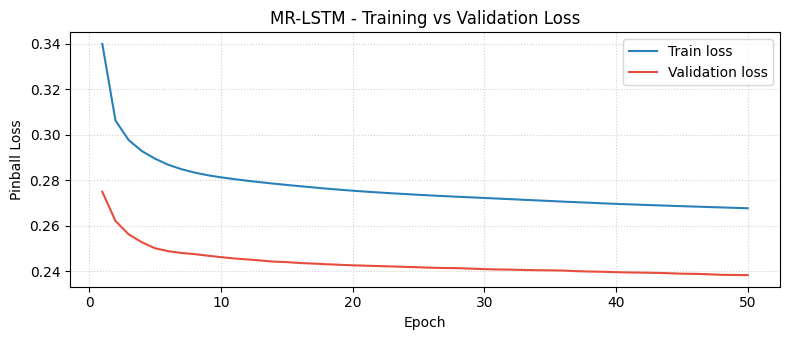

Saved: mrlstm_loss.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 3.5))
epochs_x = range(1, len(history.history["loss"]) + 1)
ax.plot(epochs_x, history.history["loss"],     label="Train loss",      color="#2980B9", linewidth=1.5)
ax.plot(epochs_x, history.history["val_loss"], label="Validation loss", color="#E74C3C", linewidth=1.5)
ax.set_xlabel("Epoch");  ax.set_ylabel("Pinball Loss")
ax.set_title("MR-LSTM - Training vs Validation Loss")
ax.legend(); ax.grid(True, linestyle=":", alpha=0.6)
fig.tight_layout()
fig.savefig("mrlstm_loss.png", dpi=180)
plt.show()
print("Saved: mrlstm_loss.png")


## 13. Visual Forecast Chart

This chart displays the predicted median price (orange line) and symmetric confidence bands ($50\%$ and $80\%$ intervals) plotted against the actual imbalance price (dashed black line) over the test window.


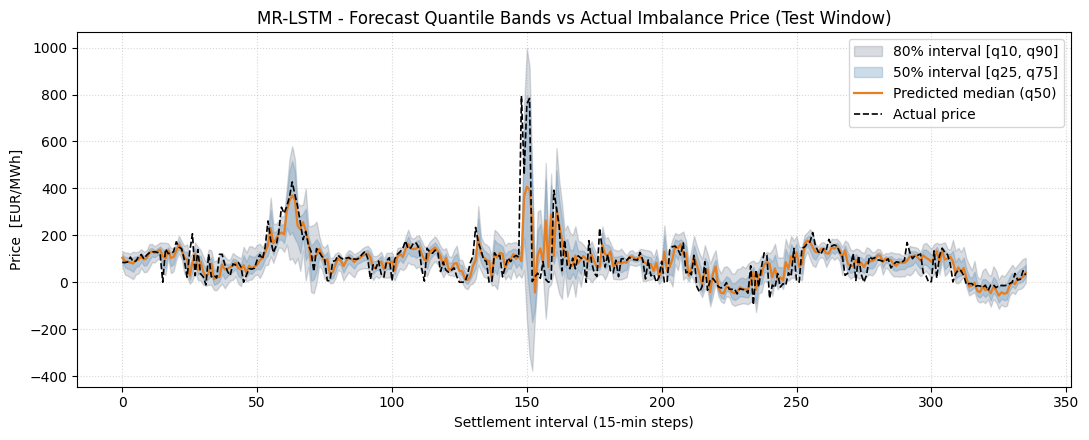

Saved: mrlstm_forecast.png


In [14]:
sample_start, sample_end = 0, 336    # ~3.5 days
df_p = comparison_df.iloc[sample_start:sample_end]
x    = np.arange(sample_start, sample_end)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(x, df_p["Pred_q10"], df_p["Pred_q90"],
                alpha=0.18, color="#2E4057", label="80% interval [q10, q90]")
ax.fill_between(x, df_p["Pred_q25"], df_p["Pred_q75"],
                alpha=0.30, color="#5B8DB8", label="50% interval [q25, q75]")
ax.plot(x, df_p["Pred_q50"], color="#E67E22", linewidth=1.6, label="Predicted median (q50)")
ax.plot(x, df_p["Actual_Price"], color="black",  linewidth=1.2,
        linestyle="--", label="Actual price")
ax.set_title("MR-LSTM - Forecast Quantile Bands vs Actual Imbalance Price (Test Window)")
ax.set_xlabel("Settlement interval (15-min steps)")
ax.set_ylabel("Price  [EUR/MWh]")
ax.legend(loc="upper right")
ax.grid(True, linestyle=":", alpha=0.5)
fig.tight_layout()
fig.savefig("mrlstm_forecast.png", dpi=200)
plt.show()
print("Saved: mrlstm_forecast.png")


## 14. Absolute Error Distribution

We plot a histogram showing how prediction errors are distributed on the test split. The dotted vertical lines show the mean absolute error (MAE) and root mean squared error (RMSE).


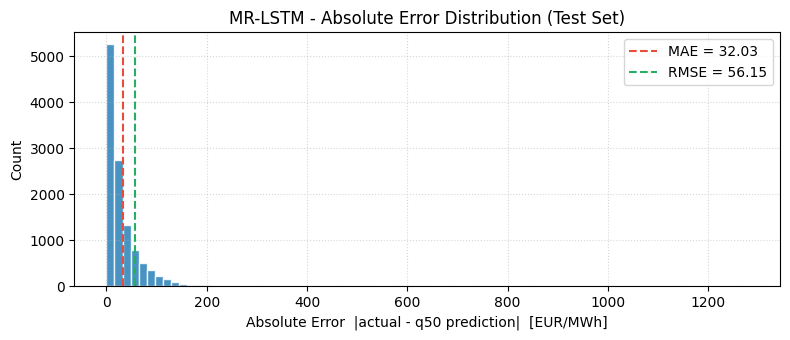

Saved: mrlstm_error_hist.png


In [15]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(comparison_df["Absolute_Error"], bins=80, color="#2980B9", edgecolor="white", alpha=0.85)
ax.axvline(metrics["MAE"],  color="#E74C3C", linestyle="--",
           linewidth=1.5, label=f"MAE = {metrics['MAE']:.2f}")
ax.axvline(metrics["RMSE"], color="#27AE60", linestyle="--",
           linewidth=1.5, label=f"RMSE = {metrics['RMSE']:.2f}")
ax.set_xlabel("Absolute Error  |actual - q50 prediction|  [EUR/MWh]")
ax.set_ylabel("Count")
ax.set_title("MR-LSTM - Absolute Error Distribution (Test Set)")
ax.legend(); ax.grid(True, linestyle=":", alpha=0.5)
fig.tight_layout()
fig.savefig("mrlstm_error_hist.png", dpi=180)
plt.show()
print("Saved: mrlstm_error_hist.png")


## 15. Execution & Results Summary Card

We print the final validation table containing all test-set metrics and lists the output files generated.


In [16]:
print("\n+--------------------------------------------------+")
print("|           MR-LSTM  Final Results Summary         |")
print("+--------------------------------------------------+")
for k, v in metrics.items():
    print(f"|  {k:<25}  {v:>10.4f}            |")
print("+--------------------------------------------------+")
print(f"Total parameters: {model.count_params():,}")
print("\nOutput files:")
print("  mrlstm_predictions.csv")
print("  mrlstm_forecast.png")
print("  mrlstm_loss.png")
print("  mrlstm_error_hist.png")



+--------------------------------------------------+
|           MR-LSTM  Final Results Summary         |
+--------------------------------------------------+
|  RMSE                          56.1534            |
|  MAE                           32.0263            |
|  R2                             0.5411            |
|  Pinball_q10%                   8.8643            |
|  Pinball_q25%                  14.2538            |
|  Pinball_q50%                  16.0131            |
|  Pinball_q75%                  13.4744            |
|  Pinball_q90%                   8.4985            |
|  AQL                           12.2208            |
|  AQCR_%                         0.0000            |
|  AQCE_%                         7.3519            |
|  AIW                           89.0846            |
+--------------------------------------------------+
Total parameters: 5,511

Output files:
  mrlstm_predictions.csv
  mrlstm_forecast.png
  mrlstm_loss.png
  mrlstm_error_hist.png
